# 01. Data Exploration - Freddie Mac SFLLD

## Summary

This notebook explores Freddie Mac's Single-Family Loan-Level Dataset (2018–2025
vintages) and builds a simplified house-price proxy from loan-implied property
values (Original UPB ÷ Original LTV). Key findings:

- Credit scores in the sample are concentrated in the 700s, consistent with
  Freddie Mac's conventional acquisition standards.
- Average implied property value rose overall from 2018–2025, but with a
  notable dip from 2021 to 2022.
- Investigating this dip revealed a sharp shift in loan-purpose composition:
  purchase loans rose from ~34% to ~67% of the pool as the 2022 rate-hike
  cycle collapsed refinance volume.
- Benchmarking against the official FHFA House Price Index showed that our
  implied-value index diverges from the true repeat-sales FHFA HPI throughout
  the sample period — not only during the 2022 shock — suggesting the metric
  is structurally sensitive to loan-mix composition rather than a reliable
  standalone price proxy.
- **Takeaway:** this exercise demonstrates both the value and the limitations
  of building house-price proxies from loan-level acquisition data, and
  motivates the use of repeat-sales or matched-property methodologies (like
  FHFA's) for accurate price measurement.

## 1. Setup & Imports

In [1]:
# check for data
with open('../data/raw/sample_2018/sample_orig_2018.txt', 'r') as f:
    for i in range(3):
        print(f.readline())

654|201803|N|204802||000|1|P|77|35|50000|77|4.5|R|N|FRM|KY|SF|42100|F18Q10000028|P|360|01|Other sellers|Other servicers|||9||7|N|7

693|201803|N|203302|24340|000|1|P|80|41|132000|80|3.25|R|N|FRM|MI|SF|49300|F18Q10000052|P|180|02|Other sellers|Other servicers|||9||1|N|7

757|201803|Y|204802||25|1|P|97|10|28000|97|4|R|N|FRM|IA|SF|51300|F18Q10000084|P|360|01|Other sellers|Other servicers|||H||7|N|Y



## 2. Load 2018 Origination Data

In [2]:
import pandas as pd

orig_columns = [
    'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
    'maturity_date', 'msa', 'mi_percent', 'number_of_units',
    'occupancy_status', 'original_cltv', 'original_dti', 'original_upb',
    'original_ltv', 'original_interest_rate', 'channel', 'ppm_flag',
    'amortization_type', 'property_state', 'property_type', 'postal_code',
    'loan_sequence_number', 'loan_purpose', 'original_loan_term',
    'number_of_borrowers', 'seller_name', 'servicer_name',
    'super_conforming_flag', 'pre_harp_loan_sequence_number',
    'program_indicator', 'harp_indicator', 'property_valuation_method',
    'interest_only_indicator', 'mi_cancellation_indicator'
]

df_2018 = pd.read_csv(
    '../data/raw/sample_2018/sample_orig_2018.txt',
    sep = '|',
    header=None,
    names=orig_columns
)

df_2018.head()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percent,number_of_units,occupancy_status,original_cltv,original_dti,...,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator
0,654,201803,N,204802,NaN,0,1,P,77,35,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
1,693,201803,N,203302,24340.0,0,1,P,80,41,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,1,N,7
2,757,201803,Y,204802,NaN,25,1,P,97,10,...,1,Other sellers,Other servicers,NaN,NaN,H,NaN,7,N,Y
3,807,201803,N,203302,NaN,0,1,P,26,38,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
4,812,201803,N,203302,19340.0,0,1,P,14,14,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,1,N,7


In [3]:
print(df_2018.shape)
df_2018.info()

(50000, 32)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   credit_score                   50000 non-null  int64  
 1   first_payment_date             50000 non-null  int64  
 2   first_time_homebuyer_flag      50000 non-null  str    
 3   maturity_date                  50000 non-null  int64  
 4   msa                            44830 non-null  float64
 5   mi_percent                     50000 non-null  int64  
 6   number_of_units                50000 non-null  int64  
 7   occupancy_status               50000 non-null  str    
 8   original_cltv                  50000 non-null  int64  
 9   original_dti                   50000 non-null  int64  
 10  original_upb                   50000 non-null  int64  
 11  original_ltv                   50000 non-null  int64  
 12  original_interest_rate         50000 non-null

## 3. Clean Special Missing-Value Codes

In [4]:
print("Credit score = 9999:", (df_2018['credit_score'] == 9999).sum())
print("DTI = 999:", (df_2018['original_dti'] == 999).sum())
print("MI% = 999:", (df_2018['mi_percent'] == 999).sum())
print("CLTV = 999:", (df_2018['original_cltv'] == 999).sum())
print("LTV = 999:", (df_2018['original_ltv'] == 999).sum())

Credit score = 9999: 14
DTI = 999: 513
MI% = 999: 0
CLTV = 999: 1
LTV = 999: 1


In [5]:
import numpy as np

# Convert the error code to NaN
df_2018['credit_score'] = df_2018['credit_score'].replace(9999, np.nan)
df_2018['original_dti'] = df_2018['original_dti'].replace(999, np.nan)
df_2018['original_cltv'] = df_2018['original_cltv'].replace(999, np.nan)
df_2018['original_ltv'] = df_2018['original_ltv'].replace(999, np.nan)

# confirm
print(df_2018[['credit_score', 'original_dti', 'original_cltv', 'original_ltv']].isna().sum())

credit_score      14
original_dti     513
original_cltv      1
original_ltv       1
dtype: int64


## 4. Exploratory Visualizations

### 4.1 Credit Score Distribution

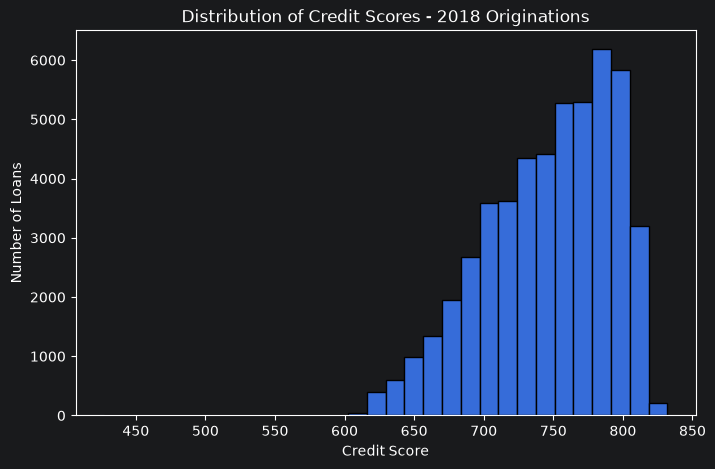

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_2018['credit_score'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Credit Score')
plt.ylabel('Number of Loans')
plt.title('Distribution of Credit Scores - 2018 Originations')
plt.show()

### 4.2 Loans by State

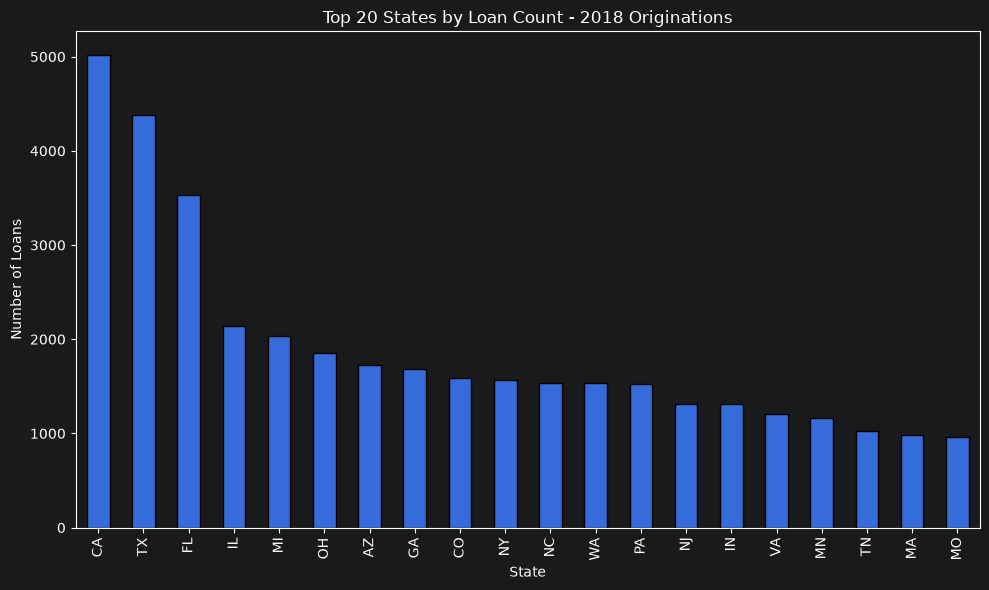

In [7]:
state_counts = df_2018['property_state'].value_counts().head(20)

plt.figure(figsize=(10,6))
state_counts.plot(kind='bar', edgecolor='black')
plt.xlabel('State')
plt.ylabel('Number of Loans')
plt.title('Top 20 States by Loan Count - 2018 Originations')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.3 Implied Property Value Distribution

count    49999.000000
mean         0.320861
std          0.197786
min          0.022105
25%          0.188000
50%          0.278947
75%          0.402500
max          2.956522
Name: implied_property_val, dtype: float64


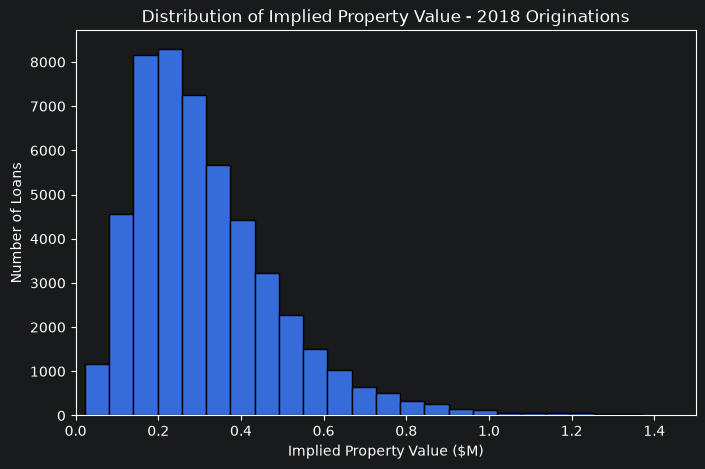

In [8]:
#Estimating the original property value
df_2018['implied_property_val'] = df_2018['original_upb']/(df_2018['original_ltv']/100)/1000000

#check the basic stats
print(df_2018['implied_property_val'].describe())

#Distribution Plot
plt.figure(figsize=(8,5))
plt.hist(df_2018['implied_property_val'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Implied Property Value ($M)')
plt.ylabel('Number of Loans')
plt.title('Distribution of Implied Property Value - 2018 Originations')
plt.xlim(0,1.5)
plt.show()

## 5. Reusable Data Loader Function

To avoid repeating the same loading and cleaning logic for each vintage year,
the `load_orig_data()` function and column schema were moved to `src/data_loader.py`.
This keeps the notebook focused on exploration and visualization, while the
reusable data-loading logic lives in a separate module that can be imported
across multiple notebooks (e.g., future default/prepayment modeling notebooks).

In [9]:
import sys
sys.path.append('../src')
from data_loader import load_orig_data, clean_orig_data

df_2019 = load_orig_data(2019)
df_2019.head()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percent,number_of_units,occupancy_status,original_cltv,original_dti,...,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator
0,741,201903,N,204902,NaN,0,1,P,80,33,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
1,731,201903,N,204902,13460.0,0,1,P,77,44,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
2,722,201903,N,204902,NaN,30,1,P,95,41,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,N
3,729,201903,N,204902,NaN,25,1,P,87,17,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,N
4,773,201903,N,204902,33700.0,0,1,P,29,43,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7


## 6. Load & Combine Multiple Vintage Years (2018-2025)

Loop through each vintage year using `load_orig_data()`, tag each dataset with
its `vintage_year`, and combine all years into a single DataFrame (`df_all`)
for cross-year analysis. Note: 2025 is a partial vintage year, so its sample
size (37,500) is proportionally smaller than other years (50,000).

In [10]:
years = range(2018,2026)

df_list = []

for year in years:
    df_year = load_orig_data(year)
    df_year['vintage_year'] = year
    df_list.append(df_year)

df_all = pd.concat(df_list, ignore_index=True)

print(df_all.shape)
df_all['vintage_year'].value_counts().sort_index()

(387500, 33)


vintage_year
2018    50000
2019    50000
2020    50000
2021    50000
2022    50000
2023    50000
2024    50000
2025    37500
Name: count, dtype: int64

In [11]:
print(df_all.shape)

(387500, 33)


## 7. Clean Combined Dataset

Apply the reusable `clean_orig_data()` function (moved to `src/data_loader.py`)
to convert special missing-value codes (e.g., 9999, 999) to NaN and compute
`implied_property_value` (Original UPB ÷ Original LTV) across the combined dataset.

In [12]:
df_all = clean_orig_data(df_all)

df_all[['credit_score', 'original_dti', 'implied_property_val']].describe()

,credit_score,original_dti,implied_property_val
count,387400.000000,386945.000000,387499.000000
mean,750.658010,36.087304,0.419243
std,44.807957,9.575364,0.264733
min,300.000000,1.000000,0.018750
25%,721.000000,29.000000,0.244565
50%,759.000000,38.000000,0.360274
75%,787.000000,44.000000,0.527778
max,848.000000,65.000000,10.000000


## 8. Trend: Average Implied Property Value by Vintage Year

Aggregate `implied_property_value` by `vintage_year` to observe how average
property values at origination have changed over time — this is an early,
simplified proxy for a house price trend index.

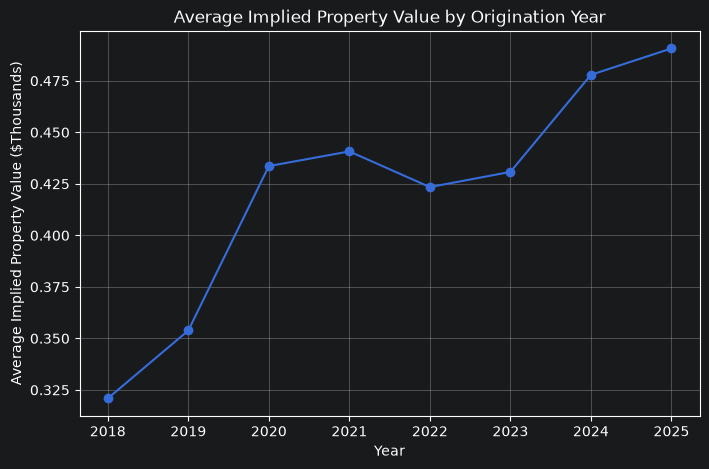

In [13]:
yearly_trend = df_all.groupby('vintage_year')['implied_property_val'].mean()

plt.figure(figsize=(8,5))
yearly_trend.plot(marker = 'o')
plt.xlabel('Year')
plt.ylabel('Average Implied Property Value ($Thousands)')
plt.title('Average Implied Property Value by Origination Year')
plt.grid(True)
plt.show()

### Observation: Dip in Average Implied Property Value (2021 → 2022)

The average implied property value declined slightly from 2021 (~0.44) to
2022 (~0.42), despite the overall upward trend across the sample period.
This coincides with the Federal Reserve's rapid rate-hiking cycle in 2022,
which may have affected the composition of Freddie Mac's acquired loan pool
in a few possible ways:

- Reduced borrower purchasing power at higher rates may have shifted the mix
  of acquired loans toward lower-priced properties.
- Refinance volume likely dropped sharply as rates rose, changing the relative
  share of purchase vs. refinance loans in the sample.
- This metric reflects the value of properties financed through Freddie Mac
  acquisitions, not a direct measure of overall market home prices — so it may
  diverge from broader indices (e.g., FHFA HPI) during periods of rate volatility.

**Note:** This is an observed pattern, not a confirmed causal explanation.
A more rigorous investigation would require comparing loan purpose (purchase
vs. refinance) mix and loan count by year, and benchmarking against the
official FHFA HPI over the same period.

## 9. Investigate: Loan Purpose Mix by Vintage Year

To test one of the hypotheses above, examine how the share of purchase vs.
refinance loans changed across vintage years — particularly around the 2022
rate-hike period.

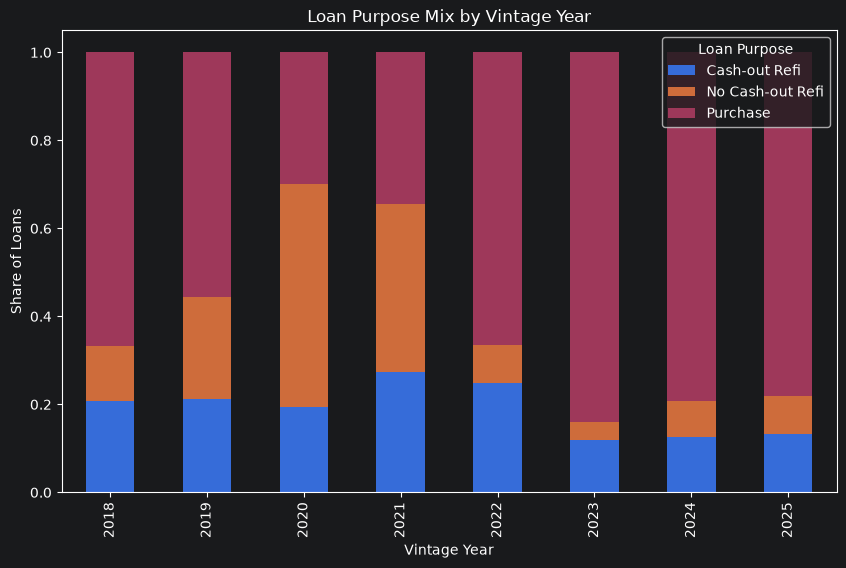

In [16]:
purpose_labels = {
    'P': 'Purchase',
    'N': 'No Cash-out Refi',
    'C': 'Cash-out Refi'
}

purpose_by_year = df_all.groupby('vintage_year')['loan_purpose'].value_counts(normalize=True).unstack()
purpose_by_year = purpose_by_year.rename(columns=purpose_labels)

purpose_by_year.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Vintage Year')
plt.ylabel('Share of Loans')
plt.title('Loan Purpose Mix by Vintage Year')
plt.legend(title='Loan Purpose')
plt.show()

### Confirmation: Purchase vs. Refinance Mix Shift in 2022

The hypothesis above is supported by the data. The share of purchase loans
rose sharply from ~34% (2021) to ~67% (2022), while no-cash-out refinance
loans fell from ~38% to ~8% over the same period — consistent with the 2022
rate-hike cycle sharply reducing refinance activity. Cash-out refinance share
remained relatively stable.

This suggests that the 2021→2022 dip in average implied property value is,
at least in part, a **composition effect**: as refinance volume collapsed,
the acquired loan pool shifted toward a larger share of purchase loans, which
may carry different average property values than the refinance loans that
previously made up a larger share of the pool. This is a more concrete
explanation than the initial hypotheses, though a full explanation would still
benefit from comparing this trend against the official FHFA HPI (which is not
subject to this compositional effect).

In [18]:
value_by_purpose_year = df_all.groupby(['vintage_year', 'loan_purpose'])['implied_property_val'].mean().unstack()
value_by_purpose_year = value_by_purpose_year.rename(columns=purpose_labels)
print(value_by_purpose_year)

loan_purpose  Cash-out Refi  No Cash-out Refi  Purchase
vintage_year                                           
2018               0.349213          0.351679  0.306334
2019               0.376393          0.423769  0.315879
2020               0.437799          0.476625  0.358237
2021               0.454338          0.471430  0.395849
2022               0.427170          0.478878  0.414800
2023               0.433663          0.533277  0.425593
2024               0.472593          0.603146  0.465758
2025               0.491947          0.611286  0.477373


### Update: Composition Effect Was Real, But Only Part of the Story

Breaking down `implied_property_value` by `loan_purpose` and year shows that
average values *within each category* (Purchase, Cash-out Refi, No Cash-out Refi)
rose consistently every year — there is no within-category dip in 2022.

The 2021→2022 dip in the *blended* average was driven by the compositional
shift described above outweighing the modest within-category price gains that
year. However, this explanation alone doesn't hold for 2023: purchase share
kept rising (to ~84%), yet the blended average resumed climbing. This is
because within-category price appreciation became large enough to outweigh the
ongoing composition drag. A weighted reconstruction (share × within-category
average, summed across purpose categories) reproduces the blended average
almost exactly, confirming this decomposition.

**Takeaway:** the implied-value series is a mix of true price appreciation and
loan-mix composition effects, which is an important caveat when using it (or
similar Freddie Mac-derived metrics) as a house-price proxy.

## 10. Benchmark Against FHFA House Price Index

Compare our implied-value trend against the official FHFA House Price Index
(Annual, All-Transactions, National), which is a true repeat-sales index and
is not subject to the loan-purpose composition effects identified above.

In [22]:
fhfa = pd.read_excel(
    '../data/raw/fhfa/hpi_at_national.xlsx',
    skiprows=5,
    names=['year', 'annual_chg_pct', 'hpi', 'hpi_1990_base', 'hpi_2000_base']
)

fhfa.head()

,year,annual_chg_pct,hpi,hpi_1990_base,hpi_2000_base
0,1975,NaN,100.00,32.62,24.36
1,1976,8.14,108.14,35.28,26.34
2,1977,16.07,125.52,40.95,30.57
3,1978,16.11,145.74,47.54,35.50
4,1979,13.90,166.00,54.15,40.43


## 11. Normalize Both Series for Comparison

FHFA HPI is indexed to 1975=100. To compare growth patterns, normalize both
our implied-value series and the FHFA HPI to the same base year (2018=100).

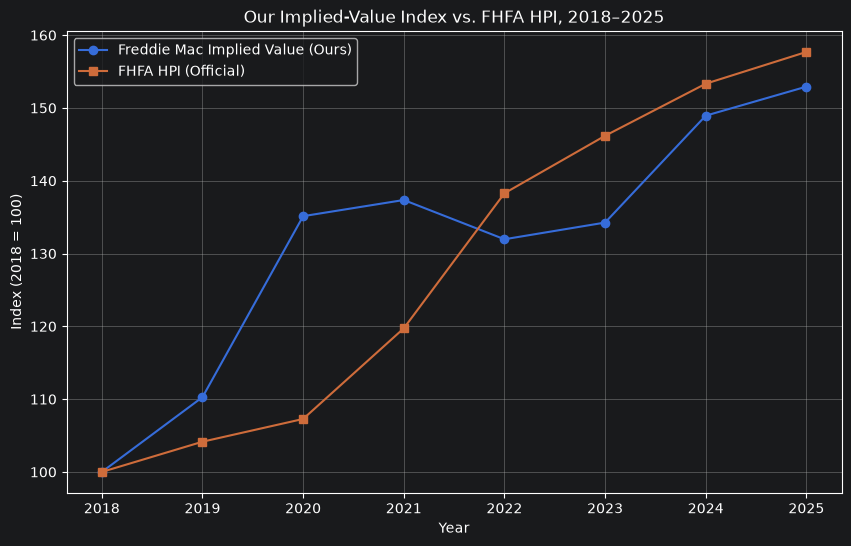

In [25]:
# Normalize both series to 2018 = 100
our_index = (yearly_trend / yearly_trend.loc[2018]) * 100

fhfa_2018_2025 = fhfa[(fhfa['year'] >= 2018) & (fhfa['year'] <= 2025)].set_index('year')['hpi']
fhfa_index = (fhfa_2018_2025 / fhfa_2018_2025.loc[2018]) * 100

# Comparison plot
plt.figure(figsize=(10, 6))
plt.plot(our_index.index, our_index.values, marker='o', label='Freddie Mac Implied Value (Ours)')
plt.plot(fhfa_index.index, fhfa_index.values, marker='s', label='FHFA HPI (Official)')
plt.xlabel('Year')
plt.ylabel('Index (2018 = 100)')
plt.title('Our Implied-Value Index vs. FHFA HPI, 2018–2025')
plt.legend()
plt.grid(True)
plt.show()

### Key Finding: Our Index Diverges from FHFA HPI Throughout the Period

Our implied-value index does not track FHFA HPI closely except the last two years. From 2018 to 2021, both indexes rise, but ours rises much faster
(137.4 vs. 119.7 by 2021 — nearly double the growth rate). From 2022 to 2023,
the divergence becomes even more pronounced and changes direction entirely:
FHFA HPI continues climbing steadily (120 → 146), while our index declines
(137 → 132) before partially recovering.

This is consistent with the composition-effect finding above, but the
magnitude of the 2018–2021 gap suggests composition effects (or other biases
in this simplified metric) were already present well before the 2022 rate
shock made them highly visible. FHFA HPI is a true repeat-sales index,
specifically constructed to control for changes in the mix of properties or
transaction types over time; our implied-value metric has no such control.

**Conclusion:** A simple average of loan-implied property values, without
controlling for loan mix or using a repeat-sales/matched-property methodology,
is not a reliable house-price proxy — the composition sensitivity is present
throughout the sample, not just during the 2022 rate shock. This underscores
why repeat-sales methodologies like FHFA's exist: to isolate true price
appreciation from compositional and sampling noise.